In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Cargar el dataset y dimensiones
df = pd.read_csv('./dataset/compas-scores-two-years.csv')
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (7214, 53)


### Preprocesamiento de Datos y Control de Calidad

In [10]:
print(f"Dimensiones del dataset: {df.shape}")
print("=" * 40)

# NaNs en el dataset
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

df_nulos = pd.DataFrame({'NaNs': nulos, '%': porcentaje_nulos})
df_nulos = df_nulos[df_nulos['NaNs'] > 0].sort_values(by='%', ascending=False)

print("Columnas con NaNs:")
print(df_nulos.round(2))

Dimensiones del dataset: (7214, 53)
Columnas con NaNs:
                         NaNs       %
violent_recid            7214  100.00
vr_offense_date          6395   88.65
vr_charge_degree         6395   88.65
vr_case_number           6395   88.65
vr_charge_desc           6395   88.65
c_arrest_date            6077   84.24
r_jail_out               4898   67.90
r_jail_in                4898   67.90
r_days_from_arrest       4898   67.90
r_charge_desc            3801   52.69
r_offense_date           3743   51.89
r_charge_degree          3743   51.89
r_case_number            3743   51.89
c_offense_date           1159   16.07
days_b_screening_arrest   307    4.26
c_jail_out                307    4.26
c_jail_in                 307    4.26
in_custody                236    3.27
out_custody               236    3.27
c_charge_desc              29    0.40
c_case_number              22    0.30
c_days_from_compas         22    0.30


Hay varias columnas de nuestro dataset que cuentan con un porcentaje de NaNs enorme, las cuales no nos sirven para nuestro modelo, por ello, descartaremos todas las columnas con un porcentaje de NaNs superior al 80%.

Luego, varias de las variables, las que tienen el prefijo "r_" hacen referencia a reincidencia, mantener estas variables sería dejarle pistas al modelo, si estas son NaN la persona no habrá reincidido, pero si tiene valor si que lo habrá hecho. Al querer crear un modelo que prediga si una persona reincidirá o no, estas variables arruinarían todo el proceso.

Por último, existen columnas que no aportan un valor real a nuestro modelo, bien sea por el desfase temporal con el que se tomaron los datos (como aquellos registros donde el arresto ocurrió con más de 30 días de diferencia respecto a la evaluación de riesgo de COMPAS), o porque carecen de relevancia predictiva para nuestro objetivo.

En este grupo se incluyen identificadores únicos personales, datos redundantes y delitos menores como infracciones de tráfico ordinarias que no corresponden al ámbito penal. Asimismo, descartaremos las instancias en las que no hay información de seguimiento real o donde el propio sistema original no llegó a emitir una puntuación de riesgo. Con esta criba, garantizamos que el modelo se entrene exclusivamente con información válida, sin ruido estadístico y respetando la lógica temporal del escenario judicial real.

In [12]:
# %%
print("Aplicando Filtros y Selección de Variables")

# 1. Filtros basados en la lógica del problema y el seguimiento real de los casos
df_filtrado = df[
    (df['days_b_screening_arrest'] <= 30) &  # Desfase temporal razonable
    (df['days_b_screening_arrest'] >= -30) & 
    (df['is_recid'] != -1) &                 # Exigimos tener seguimiento real del individuo
    (df['c_charge_degree'] != 'O') &         # Descartamos multas de tráfico
    (df['score_text'] != 'N/A')              # Exigimos que el sistema original emitiera un veredicto
].copy()

print(f"Instancias tras filtros de negocio: {df_filtrado.shape[0]}")

# 2. Selección estricta de columnas (Evitando Data Leakage y NaNs masivos)
columnas_seguras = [
    # Variables Sensibles / Demográficas
    'sex', 'age', 'age_cat', 'race',
    
    # Historial Penal Previo
    'juv_fel_count', 'juv_misd_count', 'juv_other_count',
    'priors_count', 'c_charge_degree', 'c_charge_desc',
    
    # Evaluación original
    'decile_score', 'score_text',
    
    # Target
    'two_year_recid'
]

df_seleccion = df_filtrado[columnas_seguras].copy()

# Limpieza final de NaNs residuales
df_final = df_seleccion.dropna()

print(f"Dimensiones del dataset final limpio: {df_final.shape}")
print(f"Total de filas descartadas: {df.shape[0] - df_final.shape[0]}")

df_final.to_csv('./dataset/compas_two_years_limpio.csv', index=False)

Aplicando Filtros y Selección de Variables
Instancias tras filtros de negocio: 6172
Dimensiones del dataset final limpio: (6167, 13)
Total de filas descartadas: 1047


La razón por la que los valores nulos se eliminan en lugar de reconstruirlos con valores sintéticos se basa en la ética. Estos son datos sensibles que pueden influir en la privación de la libertad de un individuo. Recontruir un historial penal mediante datos sintéticos es éticamente inaceptable, ya que los sistemas de soporte a la Decisión Judicial deben basarse en hechos fácticos y fehacientes.

In [15]:
print("\nDistribución de la variable objetivo:")
print(df_final['two_year_recid'].value_counts())



Distribución de la variable objetivo:
two_year_recid
0    3358
1    2809
Name: count, dtype: int64


### Análisis Exploratorio: Distribuciones y Sesgo Racial

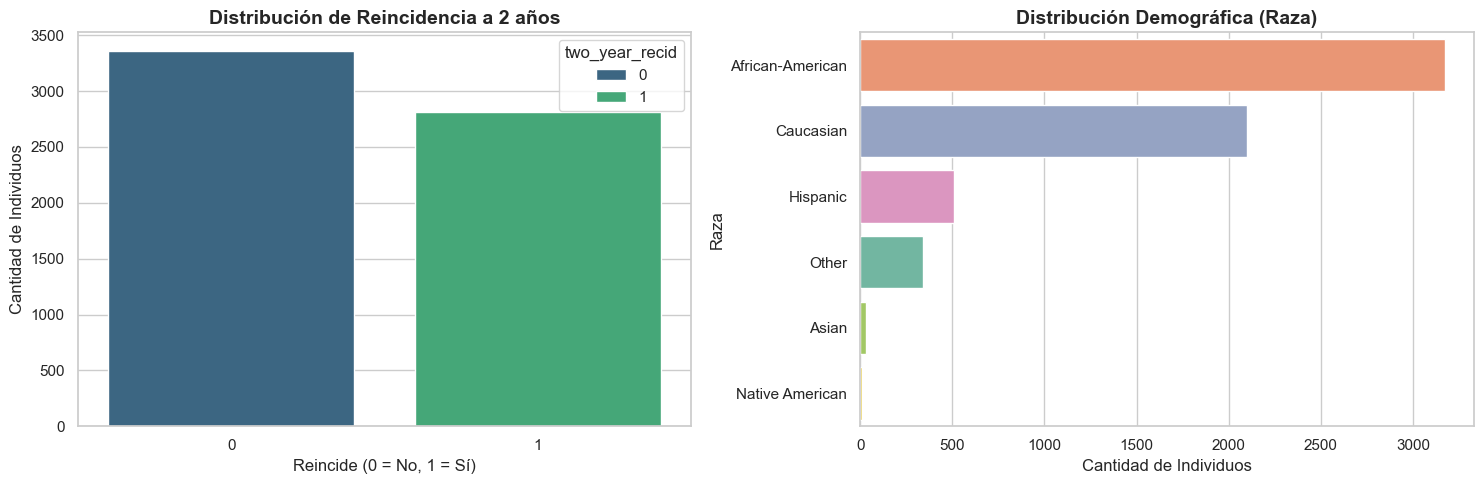

In [21]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de la variable objetivo
ax1 = sns.countplot(data=df_final, x='two_year_recid', ax=axes[0], palette='viridis', hue='two_year_recid')
axes[0].set_title('Distribución de Reincidencia a 2 años', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Reincide (0 = No, 1 = Sí)')
axes[0].set_ylabel('Cantidad de Individuos')

# Distribución de la variable Raza
ax2 = sns.countplot(data=df_final, y='race', ax=axes[1], palette='Set2', hue='race',
                    order=df_final['race'].value_counts().index)
axes[1].set_title('Distribución Demográfica (Raza)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cantidad de Individuos')
axes[1].set_ylabel('Raza')

plt.tight_layout()
plt.savefig('./Images/eda_univariado.png', dpi=400)
plt.show()

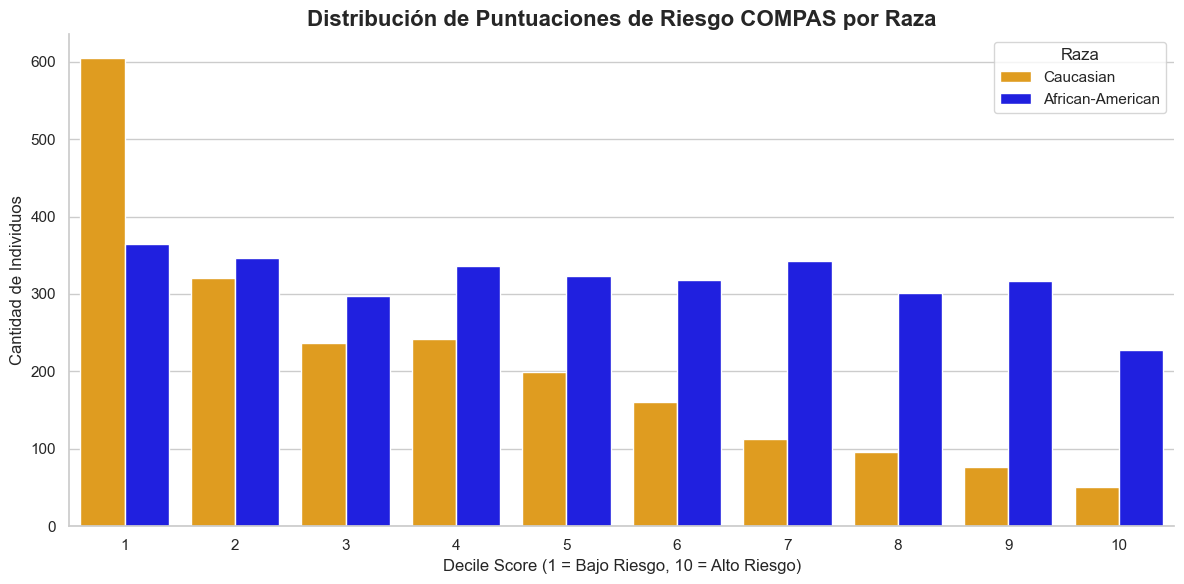

In [22]:
df_sesgo = df_final[df_final['race'].isin(['African-American', 'Caucasian'])]

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_sesgo,
    x='decile_score',
    hue='race',
    palette={'African-American': 'blue', 'Caucasian': 'orange'}
)

plt.title('Distribución de Puntuaciones de Riesgo COMPAS por Raza', fontsize=16, fontweight='bold')
plt.xlabel('Decile Score (1 = Bajo Riesgo, 10 = Alto Riesgo)', fontsize=12)
plt.ylabel('Cantidad de Individuos', fontsize=12)
plt.legend(title='Raza', fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig('./Images/eda_sesgo_racial.png', dpi=400)
plt.show()

### Matríz de Correlación

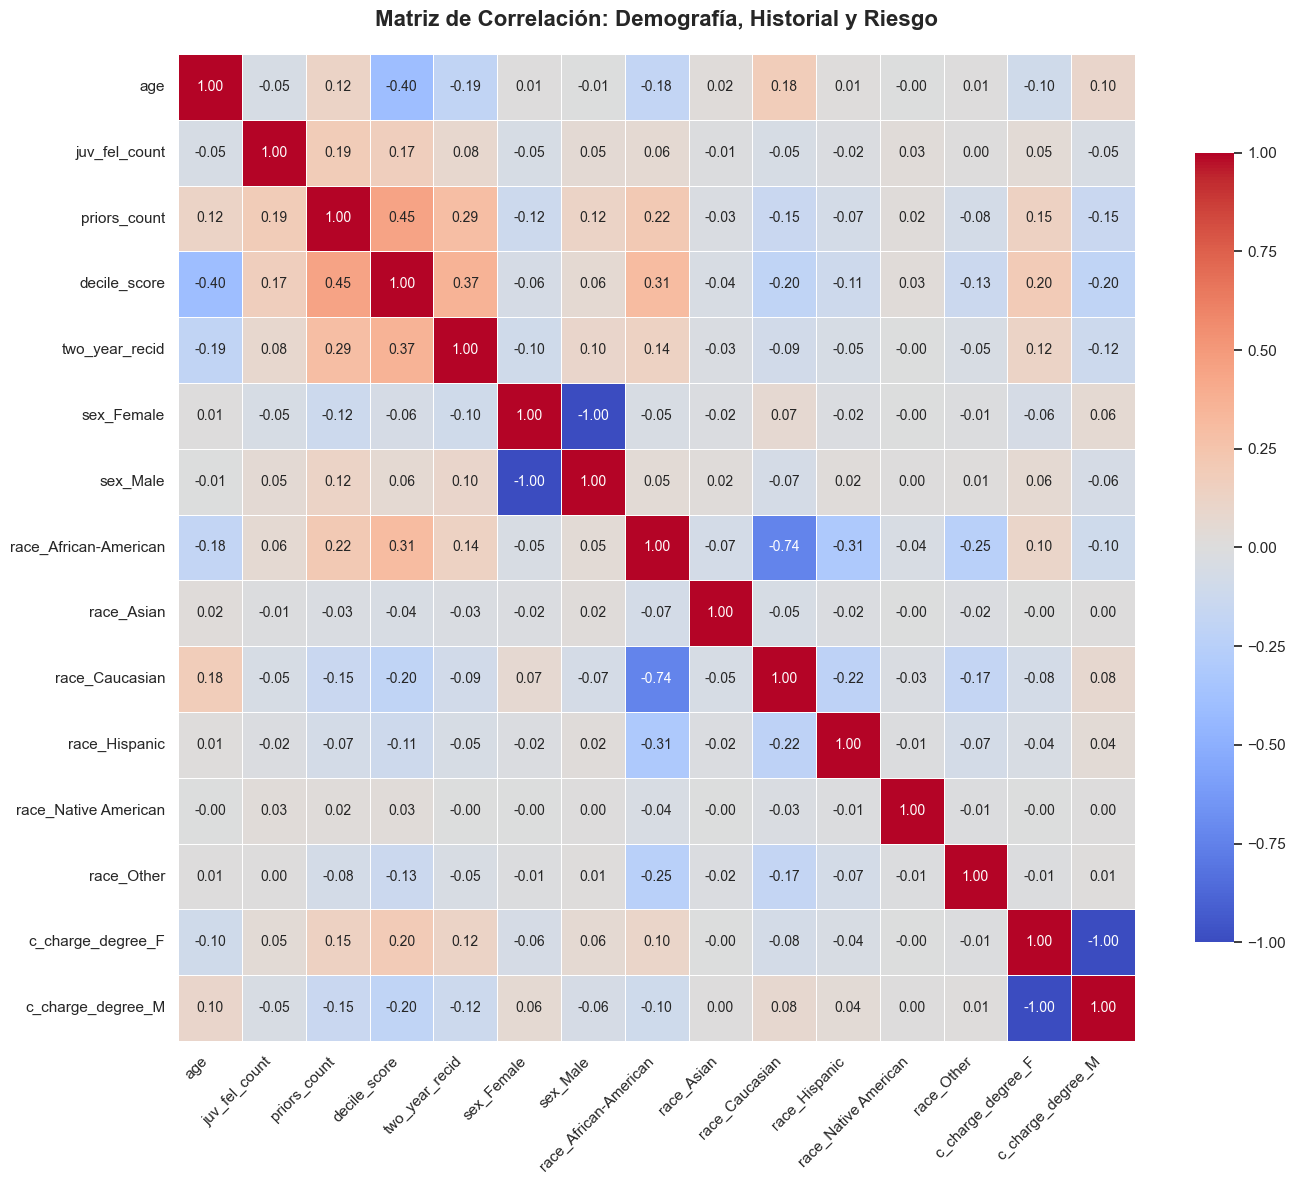

In [26]:
columnas_correlacion = [
    'sex', 'age', 'race', 'juv_fel_count', 'priors_count', 
    'c_charge_degree', 'decile_score', 'two_year_recid'
]
df_correlacion = df_final[columnas_correlacion].copy()

# 2. Convertimos las variables categóricas a variables binarias
df_correlacion = pd.get_dummies(df_correlacion, columns=['sex', 'race', 'c_charge_degree'])

# Matriz de correlación
matriz = df_correlacion.corr()

# Visualización
plt.figure(figsize=(14, 12))

sns.heatmap(
    matriz, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10}
)

plt.title('Matriz de Correlación: Demografía, Historial y Riesgo', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

plt.savefig('./Images/eda_correlacion.png', dpi=500)
plt.show()

La matriz de correlación confirma las hipótesis planteadas sobre la naturaleza del dataset y sus sesgos intrínsecos. Por un lado, se valida la coherencia predictiva general: el historial delictivo adulto (priors_count) y la edad (age) son los factores que mayor peso tienen en la puntuación de riesgo del sistema original (decile_score), con correlaciones de $0.45$ y $-0.40$ respectivamente.

Sin embargo, el hallazgo más crítico reside en la interacción entre la variable protegida y las predicciones del algoritmo. La matriz revela una disparidad evidente: la pertenencia al grupo demográfico afroamericano (race_African-American) presenta una correlación positiva ($0.31$) con la puntuación de riesgo, mientras que para la población caucásica (race_Caucasian) la correlación es negativa ($-0.20$). Adicionalmente, se detecta una correlación de $0.22$ entre la población afroamericana y el número de arrestos previos, lo que sugiere que variables predictivas aparentemente neutrales, como el historial policial, actúan en realidad como variables que codifican y perpetúan el sesgo racial sistémico en el modelo. Estas métricas justifican plenamente la necesidad de aplicar técnicas de mitigación algorítmica (Fairness) en el desarrollo del nuevo sistema.

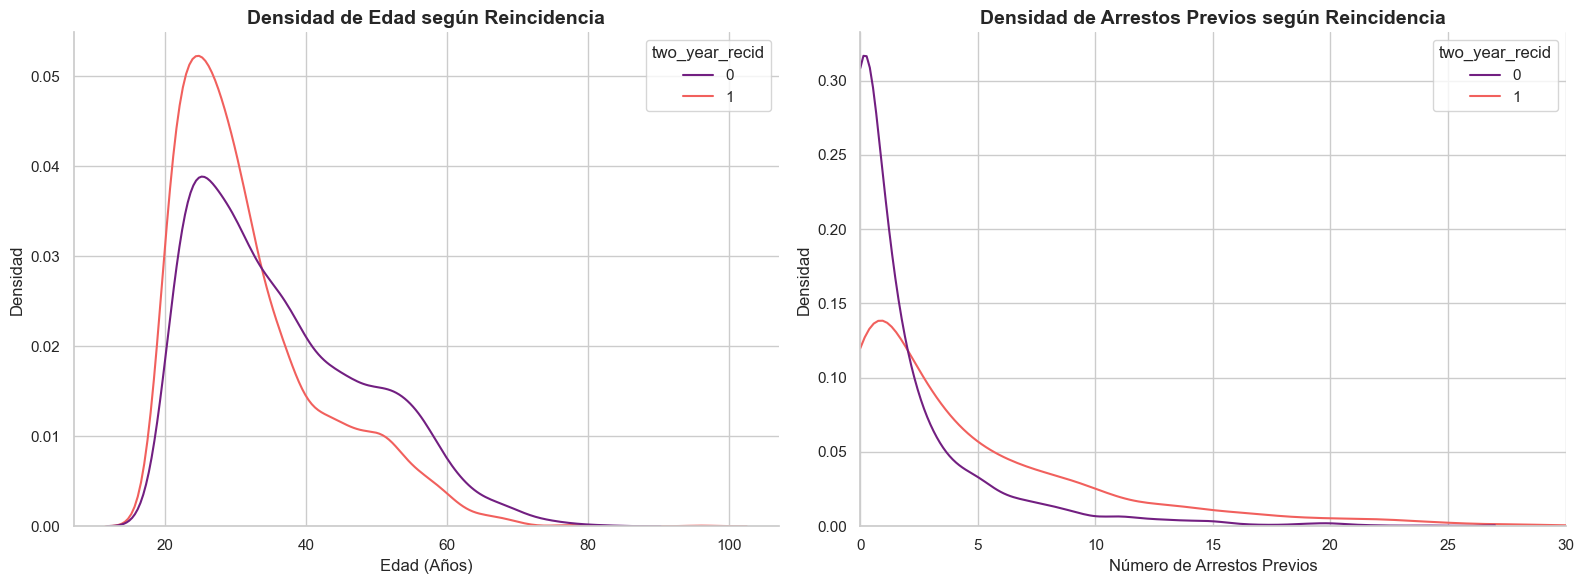

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot 1: Densidad de la Edad
sns.kdeplot(
    data=df_final, x='age', hue='two_year_recid', common_norm=False, palette='magma', ax=axes[0]
)
axes[0].set_title('Densidad de Edad según Reincidencia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Densidad')

# Plot 2: Densidad de Arrestos Previos
sns.kdeplot(
    data=df_final, x='priors_count', hue='two_year_recid', common_norm=False, palette='magma', cut=0, ax=axes[1]
)
axes[1].set_title('Densidad de Arrestos Previos según Reincidencia', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Arrestos Previos')
axes[1].set_ylabel('Densidad')
axes[1].set_xlim(0, 30)

sns.despine()
plt.tight_layout()

plt.savefig('./Images/eda_densidades_edad_priors.png', dpi=400)
plt.show()

### Outliers

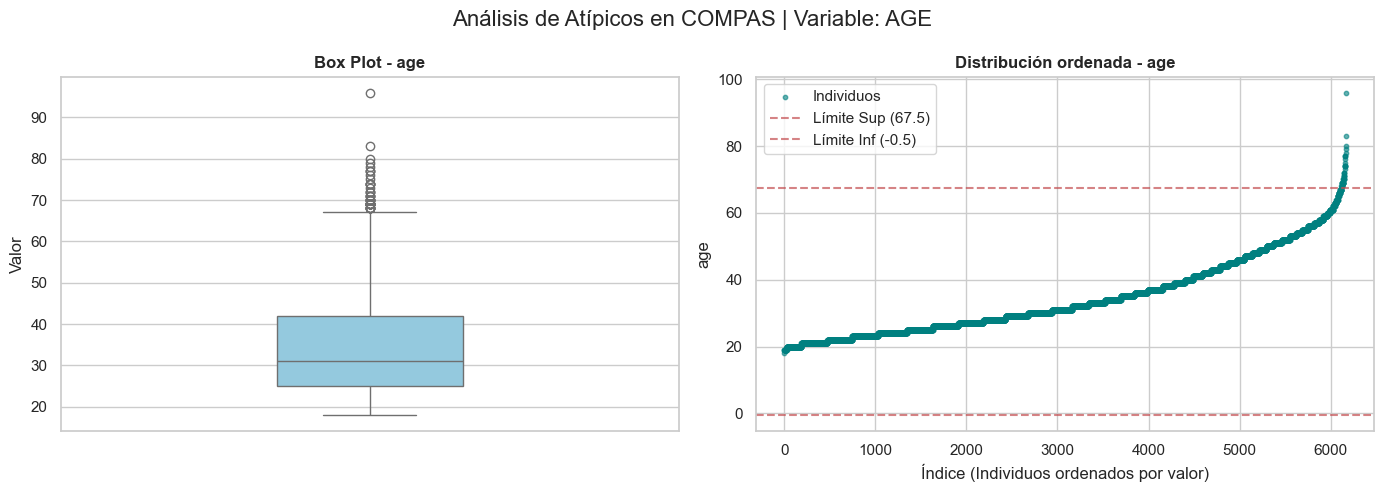

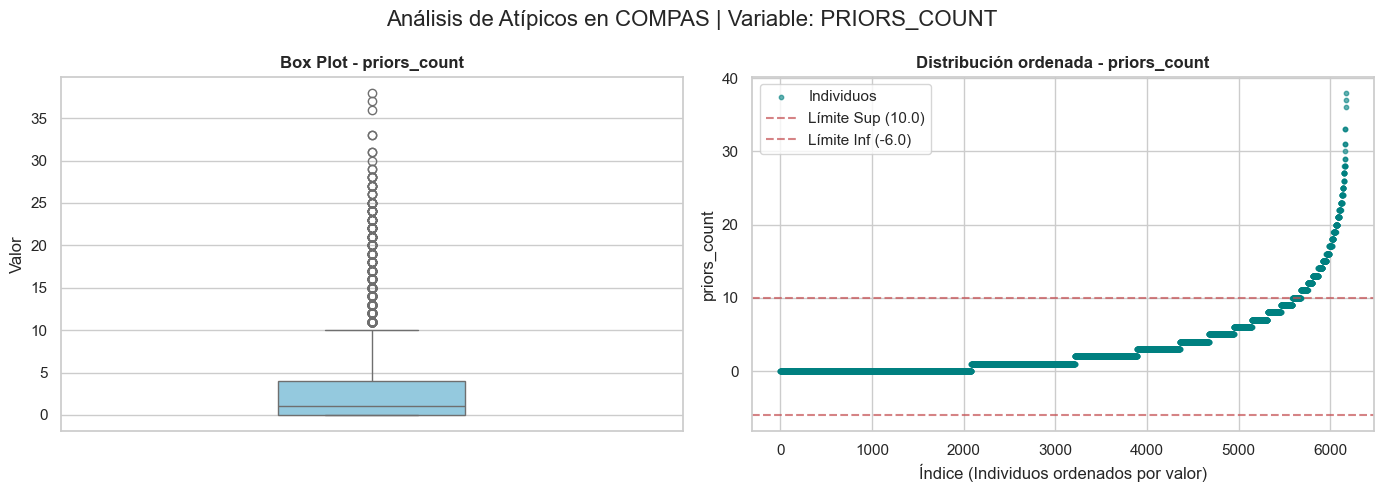

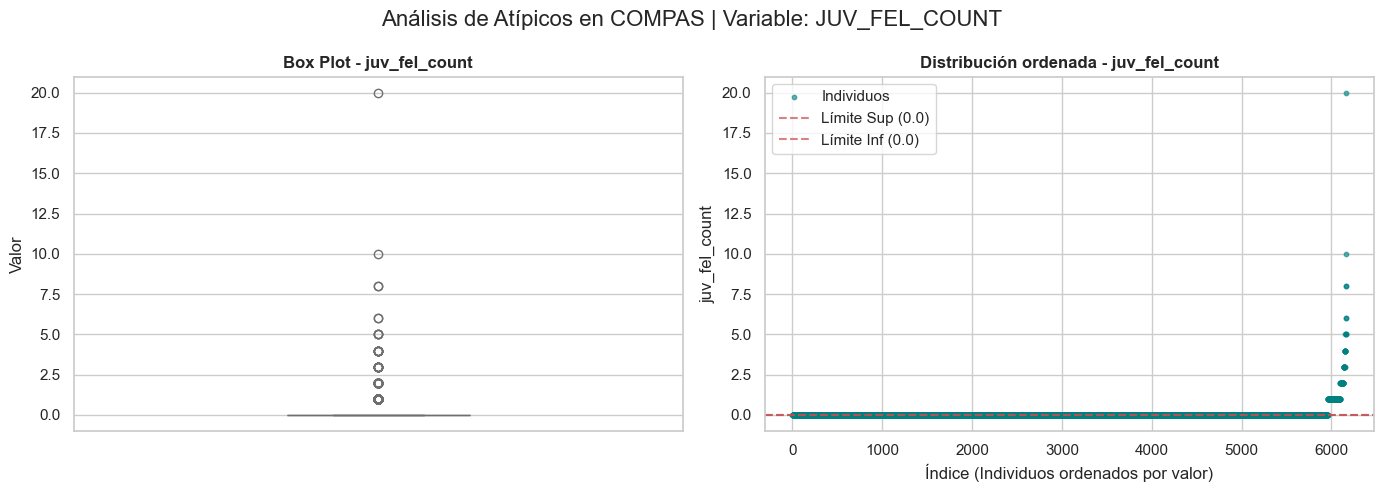

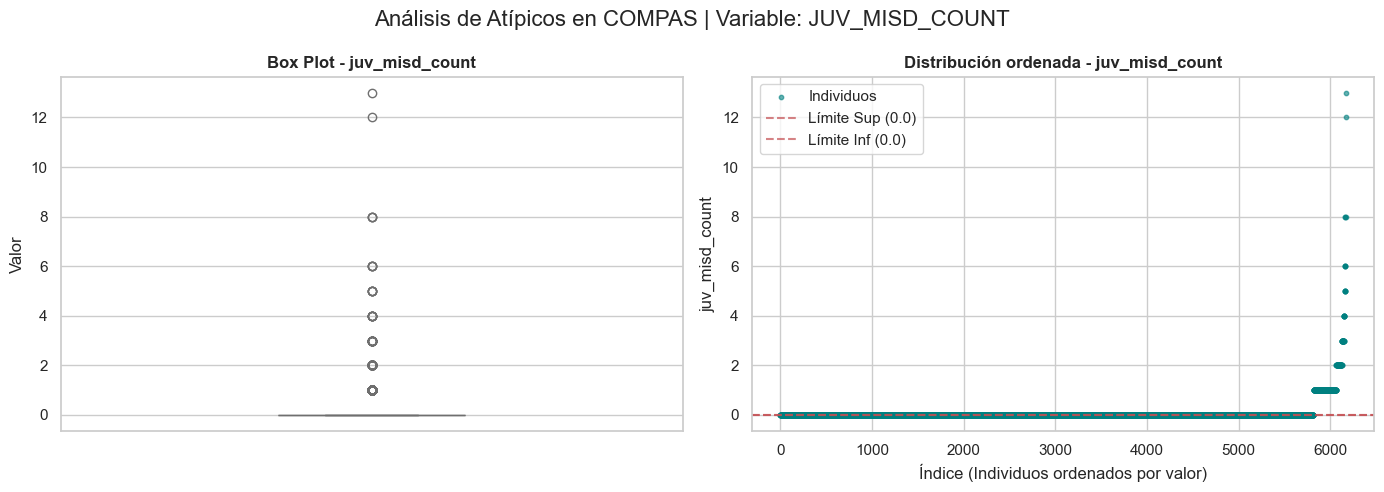

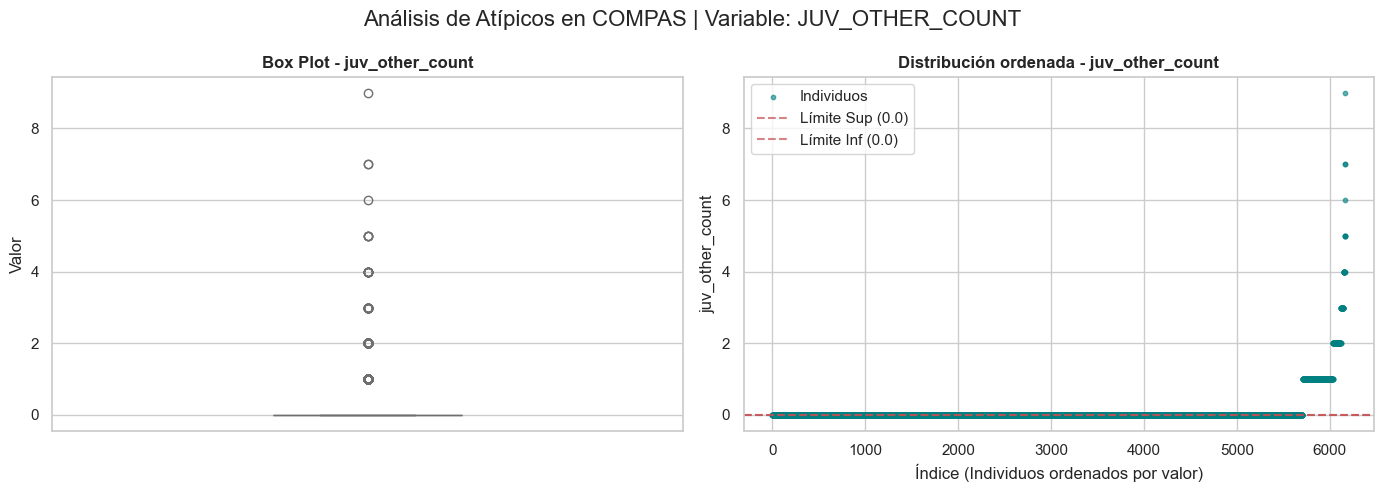

In [30]:
key_cols = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count']

sns.set_theme(style="whitegrid")

for col in key_cols:
    # IQR
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Box Plot
    sns.boxplot(y=df_final[col], ax=axes[0], color='skyblue', width=0.3)
    axes[0].set_title(f'Box Plot - {col}', fontweight='bold')
    axes[0].set_ylabel('Valor')
    
    # Gráfico 2: Scatter Plot Ordenado
    sorted_values = df_final[col].sort_values().values
    x_axis = range(len(sorted_values))
    
    axes[1].scatter(x_axis, sorted_values, s=10, alpha=0.6, color='teal', label='Individuos')
    axes[1].set_title(f'Distribución ordenada - {col}', fontweight='bold')
    axes[1].set_ylabel(col)
    axes[1].set_xlabel('Índice (Individuos ordenados por valor)')
    
    axes[1].axhline(y=upper_bound, color='r', linestyle='--', alpha=0.7, label=f'Límite Sup ({upper_bound:.1f})')
    axes[1].axhline(y=lower_bound, color='r', linestyle='--', alpha=0.7, label=f'Límite Inf ({lower_bound:.1f})')
    axes[1].legend()

    plt.suptitle(f'Análisis de Atípicos en COMPAS | Variable: {col.upper()}', fontsize=16)
    plt.tight_layout()
    
    plt.savefig(f'Images/eda_outliers_{col}.png', dpi=400, bbox_inches='tight')
    plt.show()

En las images podemos ver un comportamiento demográfico natural en la variable de la edad, ya que presenta outliers a partir de los 70 años. En el caso de los conteos juveniles, muestran como la mayoría de los acusados se concentran en 0 o muy pocos delitos previos. Sin embargo, existe una cola larga en los gráficos, un grupo reducido pero significaivo de reincidentes crónicis que superan el limite superior del IQR llegan a acumular 40 arrestos previos de adultos o 20 delitos graves en su etapa juvenil.

No existen outliers que sean errores en el dataset, por lo que no eliminaremos a ningún individuo. Además, como nuestro modelo se basa en Árboles, no aplicaremos clipping ya que el Árbol definirá sus fronteras de igual manera si el limite está en 12 delitos cometidos o sin limite con valores como 40 delitos.

### Encapsulación del Preprocesamiento de Datos
A modo de conclusión de esta fase de Análisis Exploratorio de Datos, todas las decisiones metodológicas justificadas en las secciones anteriores han sido encapsuladas en una única función modular de preprocesamiento (`load_and_clean_compas`). Esta función automatiza los filtros de calidad de la metodología oficial, el tratamiento de valores nulos, la exclusión de variables con riesgo de data leakage y la selección de atributos relevantes. Al unificar este flujo de trabajo, garantizamos la reproducibilidad del experimento, evitamos errores de manipulación manual y aseguramos que el *pipeline* de Machine Learning de la siguiente fase reciba los datos bajo los más estrictos estándares de rigor e integridad.